In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("../data/water_potability.csv")

# Imputar valores faltantes con la mediana
df["ph"] = df["ph"].fillna(df["ph"].median())
df["Sulfate"] = df["Sulfate"].fillna(df["Sulfate"].median())
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df["Trihalomethanes"].median())

# Separar X e y
X = df.drop(columns=["Potability"]).values.astype(float)
y = df["Potability"].values

# Normalización Z-score
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Split 80/20 con numpy (sin sklearn)
np.random.seed(42)
indices = np.random.permutation(len(X))
corte = int(len(X) * 0.7)

X_train = X[indices[:corte]]
X_test  = X[indices[corte:]]
y_train = y[indices[:corte]]
y_test  = y[indices[corte:]]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (2293, 9)
X_test:  (983, 9)


In [7]:
# Inicialización de pesos y sesgos
np.random.seed(42)
w_hidden = np.random.randn(8, 9) * 0.01
w_output = np.random.randn(1, 8) * 0.01

b_hidden = np.zeros((8, 1))
b_output = np.zeros((1, 1))

# Funciones de activación
relu     = lambda x: np.maximum(0, x)
logistic = lambda x: 1 / (1 + np.exp(-x))

# Derivadas
d_relu     = lambda x: (x > 0).astype(float)
d_logistic = lambda x: logistic(x) * (1 - logistic(x))

In [8]:
# Forward propagation
def forward_prop(X):
    Z1 = w_hidden @ X + b_hidden
    A1 = relu(Z1)
    Z2 = w_output @ A1 + b_output
    A2 = logistic(Z2)
    return Z1, A1, Z2, A2

# Función de costo: binary cross-entropy
def costo(A2, Y):
    return -np.mean(Y * np.log(A2 + 1e-8) + (1 - Y) * np.log(1 - A2 + 1e-8))

In [9]:
# Backpropagation
def backward_prop(Z1, A1, Z2, A2, X, Y):
    dC_dA2 = 2 * A2 - 2 * Y
    dA2_dZ2 = d_logistic(Z2)
    dZ2_dA1 = w_output
    dA1_dZ1 = d_relu(Z1)

    dC_dW2 = dC_dA2 * dA2_dZ2 @ A1.T
    dC_dB2 = dC_dA2 * dA2_dZ2

    dC_dA1 = dZ2_dA1.T @ (dC_dA2 * dA2_dZ2)
    dC_dW1 = dC_dA1 * dA1_dZ1 @ X.T
    dC_dB1 = dC_dA1 * dA1_dZ1

    return dC_dW1, dC_dB1, dC_dW2, dC_dB2

In [10]:
# Hiperparámetros
L = 0.01       # tasa de aprendizaje
epochs = 1000  # cantidad de iteraciones sobre el dataset

n = X_train.shape[0]

# Listas para guardar métricas por epoch
costo_train_l = []
costo_test_l  = []
accuracy_train_l = []
accuracy_test_l  = []

for epoch in range(epochs):
    # SGD: recorrer todos los datos de entrenamiento de a uno
    for i in range(n):
        X_sample = X_train[i].reshape(-1, 1)
        Y_sample = y_train[i]

        Z1, A1, Z2, A2 = forward_prop(X_sample)
        dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

        w_hidden -= L * dW1
        b_hidden -= L * dB1
        w_output -= L * dW2
        b_output -= L * dB2

    # Calcular métricas al final de cada epoch
    # Train
    _, _, _, A2_train = forward_prop(X_train.T)
    costo_train_l.append(costo(A2_train, y_train))
    preds_train = (A2_train >= 0.5).flatten().astype(int)
    accuracy_train_l.append(np.mean(preds_train == y_train))

    # Test
    _, _, _, A2_test = forward_prop(X_test.T)
    costo_test_l.append(costo(A2_test, y_test))
    preds_test = (A2_test >= 0.5).flatten().astype(int)
    accuracy_test_l.append(np.mean(preds_test == y_test))

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Costo train: {costo_train_l[-1]:.4f} | Accuracy test: {accuracy_test_l[-1]:.4f}")

Epoch 0 | Costo train: 0.6681 | Accuracy test: 0.6043
Epoch 100 | Costo train: 0.5783 | Accuracy test: 0.6673
Epoch 200 | Costo train: 0.5779 | Accuracy test: 0.6602
Epoch 300 | Costo train: 0.5787 | Accuracy test: 0.6541
Epoch 400 | Costo train: 0.5790 | Accuracy test: 0.6582
Epoch 500 | Costo train: 0.5791 | Accuracy test: 0.6582
Epoch 600 | Costo train: 0.5792 | Accuracy test: 0.6582
Epoch 700 | Costo train: 0.5797 | Accuracy test: 0.6582
Epoch 800 | Costo train: 0.5798 | Accuracy test: 0.6582
Epoch 900 | Costo train: 0.5798 | Accuracy test: 0.6572


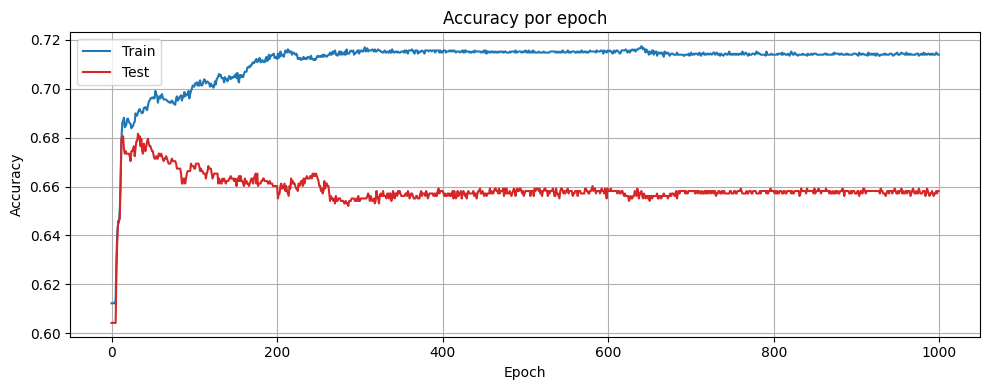

In [11]:
# Gráfico de accuracy
plt.figure(figsize=(10, 4))
plt.plot(accuracy_train_l, label='Train', color='tab:blue')
plt.plot(accuracy_test_l, label='Test', color='tab:red')
plt.title('Accuracy por epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

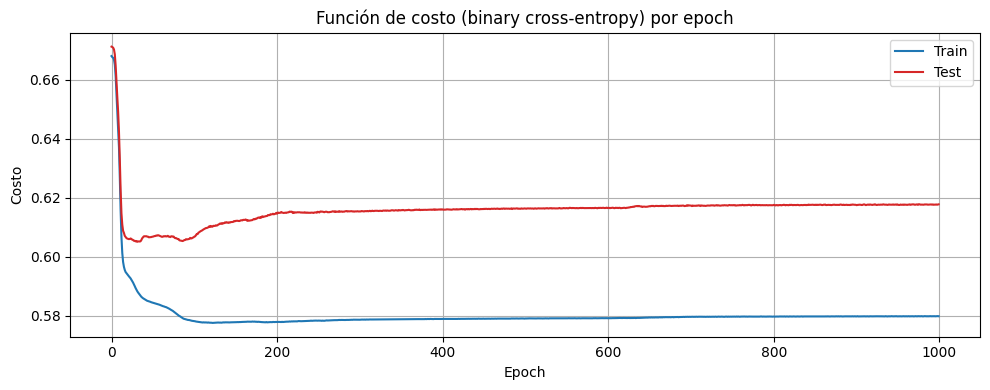

In [12]:
# Gráfico de función de costo
plt.figure(figsize=(10, 4))
plt.plot(costo_train_l, label='Train', color='tab:blue')
plt.plot(costo_test_l, label='Test', color='tab:red')
plt.title('Función de costo (binary cross-entropy) por epoch')
plt.xlabel('Epoch')
plt.ylabel('Costo')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [13]:
# Resultados finales
print(f"Accuracy train: {accuracy_train_l[-1]:.4f}")
print(f"Accuracy test:  {accuracy_test_l[-1]:.4f}")

Accuracy train: 0.7139
Accuracy test:  0.6582


In [14]:
# Buscar el epoch con mejor accuracy en test
mejor_epoch = np.argmax(accuracy_test_l)
print(f"Mejor epoch: {mejor_epoch}")
print(f"Accuracy train en ese punto: {accuracy_train_l[mejor_epoch]:.4f}")
print(f"Accuracy test en ese punto:  {accuracy_test_l[mejor_epoch]:.4f}")

Mejor epoch: 32
Accuracy train en ese punto: 0.6904
Accuracy test en ese punto:  0.6816


In [15]:
# Resetear pesos
np.random.seed(42)
w_hidden = np.random.randn(8, 9) * 0.01
w_output = np.random.randn(1, 8) * 0.01
b_hidden = np.zeros((8, 1))
b_output = np.zeros((1, 1))

In [16]:
# Reentrenar hasta el mejor epoch
L = 0.01
epochs_optimo = 32

costo_train_opt = []
costo_test_opt  = []
accuracy_train_opt = []
accuracy_test_opt  = []

for epoch in range(epochs_optimo):
    for i in range(n):
        X_sample = X_train[i].reshape(-1, 1)
        Y_sample = y_train[i]

        Z1, A1, Z2, A2 = forward_prop(X_sample)
        dW1, dB1, dW2, dB2 = backward_prop(Z1, A1, Z2, A2, X_sample, Y_sample)

        w_hidden -= L * dW1
        b_hidden -= L * dB1
        w_output -= L * dW2
        b_output -= L * dB2

    _, _, _, A2_train = forward_prop(X_train.T)
    costo_train_opt.append(costo(A2_train, y_train))
    accuracy_train_opt.append(np.mean((A2_train >= 0.5).flatten().astype(int) == y_train))

    _, _, _, A2_test = forward_prop(X_test.T)
    costo_test_opt.append(costo(A2_test, y_test))
    accuracy_test_opt.append(np.mean((A2_test >= 0.5).flatten().astype(int) == y_test))

print(f"Accuracy train final: {accuracy_train_opt[-1]:.4f}")
print(f"Accuracy test final:  {accuracy_test_opt[-1]:.4f}")

Accuracy train final: 0.6891
Accuracy test final:  0.6785


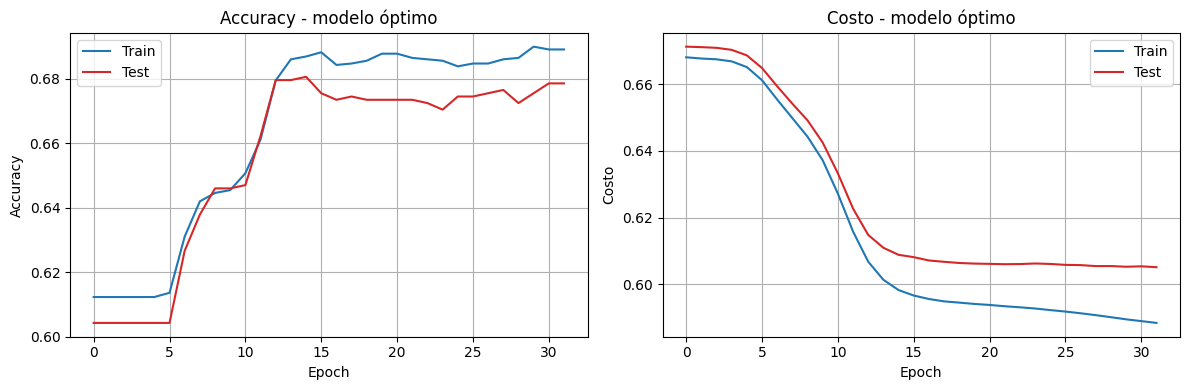

In [17]:
# Gráficos del modelo óptimo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(accuracy_train_opt, label='Train', color='tab:blue')
ax1.plot(accuracy_test_opt, label='Test', color='tab:red')
ax1.set_title('Accuracy - modelo óptimo')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid()

ax2.plot(costo_train_opt, label='Train', color='tab:blue')
ax2.plot(costo_test_opt, label='Test', color='tab:red')
ax2.set_title('Costo - modelo óptimo')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Costo')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()